# Fresh-Check ML Training Notebook v8.0

## Decision Tree with Chained CV Feature (Model Stacking)

### What's New in v8

v7 trained the gas model in isolation. v8 implements **model chaining** (a form of stacking) where the CV model's prediction is used as an additional input feature to the gas model. This was recommended by the professor as a more rigorous ML approach.

### How Chaining Works

```
CV model output (stage)
        |
        v
Cascading one-hot encoding (3 binary features)
        |
        +------> Gas Decision Tree -----> Final stage prediction
        |
Gas sliding-window features (18 features)
```

The gas Decision Tree now sees **21 features** instead of 18:
- 18 sliding-window features from MQ2 sensor (PPM stats, slopes, voltage, etc.)
- 3 cascading one-hot features from the CV model's prediction

### Cascading One-Hot Encoding

For ordinal stages (fresh < ripe < overripe < spoiled), cascading encoding preserves the ordering:

| CV stage | cv_at_least_ripe | cv_at_least_overripe | cv_at_least_spoiled |
|----------|------------------|----------------------|---------------------|
| fresh    | 0                | 0                    | 0                   |
| ripe     | 1                | 0                    | 0                   |
| overripe | 1                | 1                    | 0                   |
| spoiled  | 1                | 1                    | 1                   |

This is better than plain one-hot for ordinal data because the model can learn "is at least X" relationships.

### Synthetic CV Labels

Since our training CSV only has gas data, we generate synthetic CV labels per row:
- 85% of the time: CV agrees with the true stage
- 10% of the time: CV is off by one stage (simulates minor visual ambiguity)
- 5% of the time: CV is off by two stages (simulates major CV failure)

This trains the model to weight gas features when CV looks wrong, and trust CV when it agrees with gas patterns.

### Evaluation: Stratified 80/20 Split

Unlike v7 which trained on the full dataset and tested on synthetic data, v8 does a proper stratified train/test split on the real dataset. Each split is guaranteed to contain all four classes proportionally. We also compare with vs. without CV features to demonstrate the lift from chaining.

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
import joblib
import os
import json

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('All imports successful!')

All imports successful!


## 1. Configuration

In [2]:
CSV_FILE = 'banana_ripening_7day.csv'
OUTPUT_DIR = './models_v8'
SENSOR = 'S0'

WINDOW_SIZE = 360       # 6 hours of history at 1-min intervals
RECENT_WINDOW = 60      # 1 hour for recent trend

# Stage thresholds (PPM) — labels derived from these
# STAGE_THRESHOLDS = {
#     'fresh':    500,
#     'ripe':     2000,
#     'overripe': 5000,
# }

STAGE_THRESHOLDS = {
    'fresh':    1000,    # under 1000 = fresh (was 500)
    'ripe':     8000,    # 1000-8000 = ripe (was 2000)
    'overripe': 18000,   # 8000-18000 = overripe (was 5000)
                         # over 18000 = spoiled
}

# Stage ordering (for cascading encoding and noise injection)
STAGE_ORDER = ['fresh', 'ripe', 'overripe', 'spoiled']

# Synthetic CV noise distribution
CV_NOISE_AGREE = 0.85   # CV matches true stage
CV_NOISE_OFF1  = 0.10   # CV is off by 1 stage (split between +1 and -1)
CV_NOISE_OFF2  = 0.05   # CV is off by 2 stages

STAGE_TO_ACTION = {
    'fresh':    'maintain_display',
    'ripe':     'promote_for_sale',
    'overripe': 'apply_discount',
    'spoiled':  'remove_from_shelf'
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Configuration loaded. Output: {OUTPUT_DIR}')

Configuration loaded. Output: ./models_v8


## 2. Load Data

In [3]:
df = pd.read_csv(CSV_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f'Loaded {len(df)} readings')
print(f'Date range: {df["Timestamp"].min()} to {df["Timestamp"].max()}')
print(f'PPM range: {df[f"{SENSOR}_PPM"].min():.0f} to {df[f"{SENSOR}_PPM"].max():.0f}')

df.head()

Loaded 1008 readings
Date range: 2026-03-21 21:27:34 to 2026-03-28 21:17:34
PPM range: 152 to 10015


,Timestamp,S0_V,S0_PPM,S1_V,S1_PPM,S2_V,S2_PPM
0,2026-03-21 21:27:34,0.37,240.70,0.36,157.87,0.38,190.53
1,2026-03-21 21:37:34,0.34,226.98,0.38,185.58,0.39,184.78
2,2026-03-21 21:47:34,0.38,184.67,0.36,209.58,0.39,214.38
3,2026-03-21 21:57:34,0.34,240.61,0.34,193.55,0.39,220.37
4,2026-03-21 22:07:34,0.35,239.97,0.37,212.02,0.39,182.44


## 3. Feature Engineering (same 18 features as v7)

In [4]:
def engineer_features(df, sensor_prefix, start_time):
    """Engineer 18 sliding window features from raw sensor readings."""
    v_col = f'{sensor_prefix}_V'
    ppm_col = f'{sensor_prefix}_PPM'

    features_list = []

    for i in range(WINDOW_SIZE, len(df)):
        window = df.iloc[i-WINDOW_SIZE:i]
        recent = df.iloc[i-RECENT_WINDOW:i]
        current = df.iloc[i]

        hours_elapsed = (current['Timestamp'] - start_time).total_seconds() / 3600

        ppm_values = window[ppm_col].values
        ppm_mean = np.mean(ppm_values)
        ppm_std = np.std(ppm_values)
        ppm_median = np.median(ppm_values)
        ppm_min = np.min(ppm_values)
        ppm_max = np.max(ppm_values)
        ppm_range = ppm_max - ppm_min
        ppm_current = current[ppm_col]
        ppm_cv = ppm_std / ppm_mean if ppm_mean > 0 else 0

        x_hours = np.arange(len(ppm_values)) * (10/60)
        slope_result = stats.linregress(x_hours, ppm_values)
        ppm_slope = slope_result.slope
        ppm_r_squared = slope_result.rvalue**2

        recent_ppm = recent[ppm_col].values
        recent_slope = 0
        if len(recent_ppm) >= 3:
            x_recent = np.arange(len(recent_ppm)) * (10/60)
            recent_slope = stats.linregress(x_recent, recent_ppm).slope

        ppm_acceleration = recent_slope - ppm_slope

        v_values = window[v_col].values
        v_mean = np.mean(v_values)
        v_std = np.std(v_values)
        v_current = current[v_col]
        v_slope = stats.linregress(x_hours, v_values).slope

        ppm_q25 = np.percentile(ppm_values, 25)
        ppm_q75 = np.percentile(ppm_values, 75)
        ppm_iqr = ppm_q75 - ppm_q25

        features_list.append({
            'timestamp': current['Timestamp'],
            'hours_elapsed': hours_elapsed,
            'ppm_current': ppm_current,
            'ppm_mean': ppm_mean,
            'ppm_median': ppm_median,
            'ppm_std': ppm_std,
            'ppm_min': ppm_min,
            'ppm_max': ppm_max,
            'ppm_range': ppm_range,
            'ppm_cv': ppm_cv,
            'ppm_slope': ppm_slope,
            'ppm_r_squared': ppm_r_squared,
            'ppm_q25': ppm_q25,
            'ppm_q75': ppm_q75,
            'ppm_iqr': ppm_iqr,
            'recent_slope': recent_slope,
            'ppm_acceleration': ppm_acceleration,
            'v_mean': v_mean,
            'v_std': v_std,
            'v_current': v_current,
            'v_slope': v_slope,
        })

    return pd.DataFrame(features_list)

start_time = df['Timestamp'].min()
features_df = engineer_features(df, SENSOR, start_time)
print(f'Generated {len(features_df)} feature samples')

Generated 648 feature samples


## 4. Generate True Labels (from PPM thresholds)

In [5]:
def assign_stage(ppm_mean):
    if ppm_mean < STAGE_THRESHOLDS['fresh']:
        return 'fresh'
    elif ppm_mean < STAGE_THRESHOLDS['ripe']:
        return 'ripe'
    elif ppm_mean < STAGE_THRESHOLDS['overripe']:
        return 'overripe'
    else:
        return 'spoiled'

features_df['true_stage'] = features_df['ppm_mean'].apply(assign_stage)

# Distribution
print('True label distribution:')
for stage in STAGE_ORDER:
    count = (features_df['true_stage'] == stage).sum()
    print(f'  {stage:10s}: {count:4d} samples ({count/len(features_df)*100:.1f}%)')

True label distribution:
  fresh     :  233 samples (36.0%)
  ripe      :  415 samples (64.0%)
  overripe  :    0 samples (0.0%)
  spoiled   :    0 samples (0.0%)


## 5. Generate Synthetic CV Labels (with realistic noise)

The CV model in production won't be perfect — sometimes it'll disagree with the true stage. We simulate this by injecting noise into the CV labels during training. This teaches the gas model to handle CV/gas disagreement intelligently.

In [6]:
def generate_synthetic_cv_label(true_stage, rng):
    """
    Generate a noisy CV stage based on the true stage.
    - 85% agree
    - 10% off by one (split between +1 and -1)
    - 5% off by two
    """
    true_idx = STAGE_ORDER.index(true_stage)
    roll = rng.random()

    if roll < CV_NOISE_AGREE:
        # CV agrees with true stage
        return true_stage
    elif roll < CV_NOISE_AGREE + CV_NOISE_OFF1:
        # Off by one stage in either direction
        offset = rng.choice([-1, 1])
        cv_idx = max(0, min(len(STAGE_ORDER) - 1, true_idx + offset))
        return STAGE_ORDER[cv_idx]
    else:
        # Off by two stages
        offset = rng.choice([-2, 2])
        cv_idx = max(0, min(len(STAGE_ORDER) - 1, true_idx + offset))
        return STAGE_ORDER[cv_idx]

# Apply with fixed seed for reproducibility
rng = np.random.default_rng(seed=42)
features_df['cv_stage'] = features_df['true_stage'].apply(
    lambda s: generate_synthetic_cv_label(s, rng)
)

# Show agreement rate
agreement = (features_df['cv_stage'] == features_df['true_stage']).mean()
print(f'CV-True agreement rate: {agreement:.1%}')
print(f'\nCV vs True confusion (rows = true, columns = CV):')
print(pd.crosstab(features_df['true_stage'], features_df['cv_stage'],
                  rownames=['True'], colnames=['CV']))

CV-True agreement rate: 88.0%

CV vs True confusion (rows = true, columns = CV):
CV     fresh  overripe  ripe  spoiled
True                                 
fresh    219         5     9        0
ripe      33        23   351        8


## 6. Cascading One-Hot Encoding

Convert the ordinal CV stage into 3 binary features that preserve ordering.

In [7]:
def cascading_one_hot(stage):
    """
    Cascading one-hot for ordinal stages.

    fresh    -> [0, 0, 0]
    ripe     -> [1, 0, 0]
    overripe -> [1, 1, 0]
    spoiled  -> [1, 1, 1]

    Returns: [cv_at_least_ripe, cv_at_least_overripe, cv_at_least_spoiled]
    """
    idx = STAGE_ORDER.index(stage)
    return [
        1 if idx >= 1 else 0,  # at least ripe
        1 if idx >= 2 else 0,  # at least overripe
        1 if idx >= 3 else 0,  # at least spoiled
    ]

# Apply encoding
encoded = features_df['cv_stage'].apply(cascading_one_hot)
features_df['cv_at_least_ripe'] = encoded.apply(lambda x: x[0])
features_df['cv_at_least_overripe'] = encoded.apply(lambda x: x[1])
features_df['cv_at_least_spoiled'] = encoded.apply(lambda x: x[2])

print('Cascading encoding sample:')
print(features_df[['cv_stage', 'cv_at_least_ripe',
                   'cv_at_least_overripe', 'cv_at_least_spoiled']].head(8))

Cascading encoding sample:
   cv_stage  cv_at_least_ripe  cv_at_least_overripe  cv_at_least_spoiled
0     fresh                 0                     0                    0
1     fresh                 0                     0                    0
2     fresh                 0                     0                    0
3     fresh                 0                     0                    0
4  overripe                 1                     1                    0
5     fresh                 0                     0                    0
6     fresh                 0                     0                    0
7     fresh                 0                     0                    0


## 7. Prepare Feature Matrix

Two versions for comparison:
- **Gas-only**: 18 features (baseline, like v7)
- **Chained**: 18 gas + 3 CV = 21 features (the new approach)

We exclude `ppm_mean` and `ppm_median` because labels are derived from them (avoids leakage).

In [8]:
EXCLUDE_COLS = [
    'timestamp', 'true_stage', 'cv_stage',
    'ppm_mean', 'ppm_median',
    'cv_at_least_ripe', 'cv_at_least_overripe', 'cv_at_least_spoiled',
]

# Gas-only feature columns
gas_only_cols = [c for c in features_df.columns
                 if c not in EXCLUDE_COLS]

# Chained feature columns (gas + CV)
chained_cols = gas_only_cols + [
    'cv_at_least_ripe',
    'cv_at_least_overripe',
    'cv_at_least_spoiled',
]

print(f'Gas-only features: {len(gas_only_cols)}')
print(f'Chained features:  {len(chained_cols)}')

X_gas_only = features_df[gas_only_cols].values
X_chained = features_df[chained_cols].values
y = features_df['true_stage'].values

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(STAGE_ORDER)
y_encoded = label_encoder.transform(y)

print(f'\nTotal samples: {len(X_chained)}')
print(f'Classes: {list(label_encoder.classes_)}')

Gas-only features: 18
Chained features:  21

Total samples: 648
Classes: [np.str_('fresh'), np.str_('overripe'), np.str_('ripe'), np.str_('spoiled')]


## 8. Stratified 80/20 Train/Test Split

Stratified sampling ensures both train and test sets contain all four classes in the same proportion as the full dataset. This is the standard approach for classification problems and avoids the failure mode where one class is missing from a split.

In [9]:
# Stratified split — same indices for both feature sets
indices = np.arange(len(y_encoded))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

X_gas_train = X_gas_only[train_idx]
X_gas_test = X_gas_only[test_idx]
X_chained_train = X_chained[train_idx]
X_chained_test = X_chained[test_idx]
y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]

print(f'Training samples: {len(train_idx)}')
print(f'Test samples:     {len(test_idx)}')
print(f'\nTrain class distribution:')
for stage_idx, stage in enumerate(label_encoder.classes_):
    count = (y_train == stage_idx).sum()
    print(f'  {stage:10s}: {count:4d}')
print(f'\nTest class distribution:')
for stage_idx, stage in enumerate(label_encoder.classes_):
    count = (y_test == stage_idx).sum()
    print(f'  {stage:10s}: {count:4d}')

Training samples: 518
Test samples:     130

Train class distribution:
  fresh     :  186
  overripe  :    0
  ripe      :  332
  spoiled   :    0

Test class distribution:
  fresh     :   47
  overripe  :    0
  ripe      :   83
  spoiled   :    0


## 9. Cross-Validation: Find Best Tree Depth

In [10]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('5-fold CV on chained features:')
print('=' * 65)
print(f'{"Depth":>8}  {"Accuracy":>10}  {"F1 (macro)":>12}  {"Std":>8}')
print('-' * 65)

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=5,
        random_state=42
    )
    acc_scores = cross_val_score(dt, X_chained_train, y_train, cv=skf, scoring='accuracy')
    f1_scores = cross_val_score(dt, X_chained_train, y_train, cv=skf, scoring='f1_macro')

    depth_str = str(depth) if depth else 'None'
    results.append({
        'depth': depth,
        'acc_mean': acc_scores.mean(),
        'acc_std': acc_scores.std(),
        'f1_mean': f1_scores.mean(),
    })
    print(f'{depth_str:>8}  {acc_scores.mean():>10.4f}  {f1_scores.mean():>12.4f}  {acc_scores.std():>8.4f}')

5-fold CV on chained features:
   Depth    Accuracy    F1 (macro)       Std
-----------------------------------------------------------------
       2      0.9981        0.9979    0.0039
       3      0.9981        0.9979    0.0039
       4      0.9981        0.9979    0.0039
       5      0.9981        0.9979    0.0039
       6      0.9981        0.9979    0.0039
       8      0.9981        0.9979    0.0039
      10      0.9981        0.9979    0.0039
    None      0.9981        0.9979    0.0039


## 10. Train Both Models on the Training Set

In [11]:
BEST_DEPTH = 4

# Model 1: Gas-only (baseline, like v7)
gas_only_model = DecisionTreeClassifier(
    max_depth=BEST_DEPTH,
    min_samples_leaf=5,
    random_state=42
)
gas_only_model.fit(X_gas_train, y_train)

# Model 2: Chained (gas + CV)
chained_model = DecisionTreeClassifier(
    max_depth=BEST_DEPTH,
    min_samples_leaf=5,
    random_state=42
)
chained_model.fit(X_chained_train, y_train)

print('Both models trained.')
print(f'\nGas-only:  {gas_only_model.get_n_leaves()} leaves, depth {gas_only_model.get_depth()}')
print(f'Chained:   {chained_model.get_n_leaves()} leaves, depth {chained_model.get_depth()}')

Both models trained.

Gas-only:  2 leaves, depth 1
Chained:   2 leaves, depth 1


## 11. Evaluate on Held-Out Test Set

In [12]:
# Predict on test set with both models
y_pred_gas = gas_only_model.predict(X_gas_test)
y_pred_chained = chained_model.predict(X_chained_test)

# Metrics
acc_gas = accuracy_score(y_test, y_pred_gas)
acc_chained = accuracy_score(y_test, y_pred_chained)
f1_gas = f1_score(y_test, y_pred_gas, average='macro')
f1_chained = f1_score(y_test, y_pred_chained, average='macro')

print('=' * 60)
print('TEST SET RESULTS')
print('=' * 60)
print(f'{"Model":<20} {"Accuracy":>12} {"F1 (macro)":>12}')
print('-' * 60)
print(f'{"Gas-only (v7)":<20} {acc_gas:>12.4f} {f1_gas:>12.4f}')
print(f'{"Chained (v8)":<20} {acc_chained:>12.4f} {f1_chained:>12.4f}')
print('-' * 60)
lift_acc = (acc_chained - acc_gas) * 100
lift_f1 = (f1_chained - f1_gas) * 100
print(f'{"Lift from chaining":<20} {lift_acc:>+11.2f}% {lift_f1:>+11.2f}%')

TEST SET RESULTS
Model                    Accuracy   F1 (macro)
------------------------------------------------------------
Gas-only (v7)              0.9923       0.9916
Chained (v8)               0.9846       0.9833
------------------------------------------------------------
Lift from chaining         -0.77%       -0.83%


In [15]:
# Detailed classification reports
print('Gas-only (v7) classification report:')
print(classification_report(y_test, y_pred_gas,
                            target_names=label_encoder.classes_,
                            zero_division=0))

print('\nChained (v8) classification report:')
print(classification_report(y_test, y_pred_chained,
                            target_names=label_encoder.classes_,
                            zero_division=0))

Gas-only (v7) classification report:


ValueError: Number of classes, 2, does not match size of target_names, 4. Try specifying the labels parameter

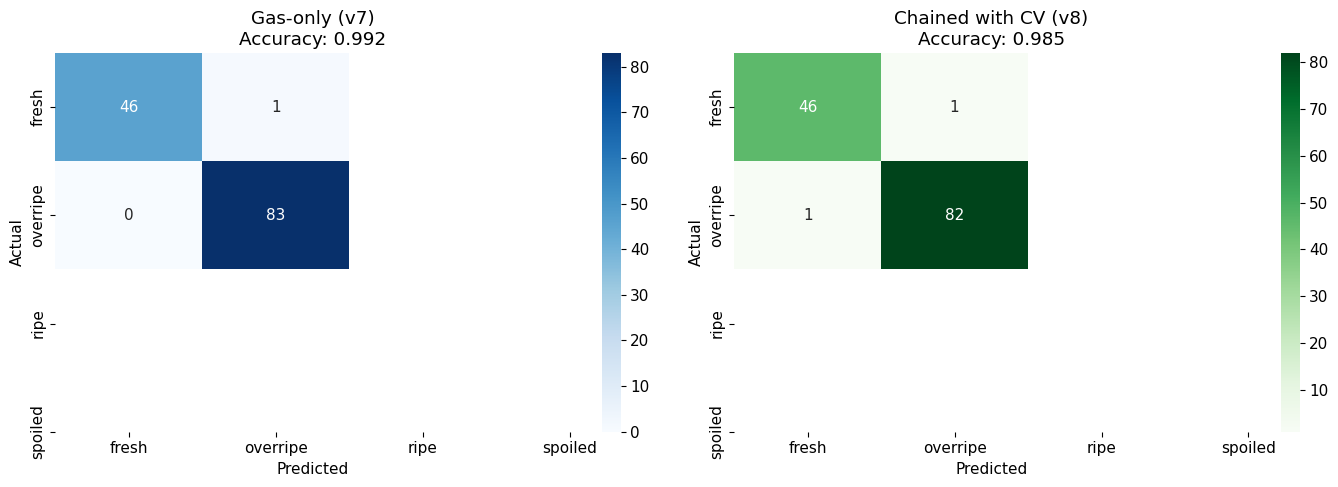

In [14]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_gas = confusion_matrix(y_test, y_pred_gas)
sns.heatmap(cm_gas, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[0].set_title(f'Gas-only (v7)\nAccuracy: {acc_gas:.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_chained = confusion_matrix(y_test, y_pred_chained)
sns.heatmap(cm_chained, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[1].set_title(f'Chained with CV (v8)\nAccuracy: {acc_chained:.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 12. Visualise the Chained Tree

In [16]:
print('Chained Decision Tree Rules:')
print('=' * 70)
tree_rules = export_text(chained_model,
                         feature_names=chained_cols,
                         class_names=list(label_encoder.classes_))
print(tree_rules)

Chained Decision Tree Rules:
|--- ppm_q75 <= 528.93
|   |--- class: fresh
|--- ppm_q75 >  528.93
|   |--- ppm_q25 <= 1914.17
|   |   |--- class: ripe
|   |--- ppm_q25 >  1914.17
|   |   |--- ppm_q25 <= 4846.69
|   |   |   |--- class: overripe
|   |   |--- ppm_q25 >  4846.69
|   |   |   |--- class: spoiled



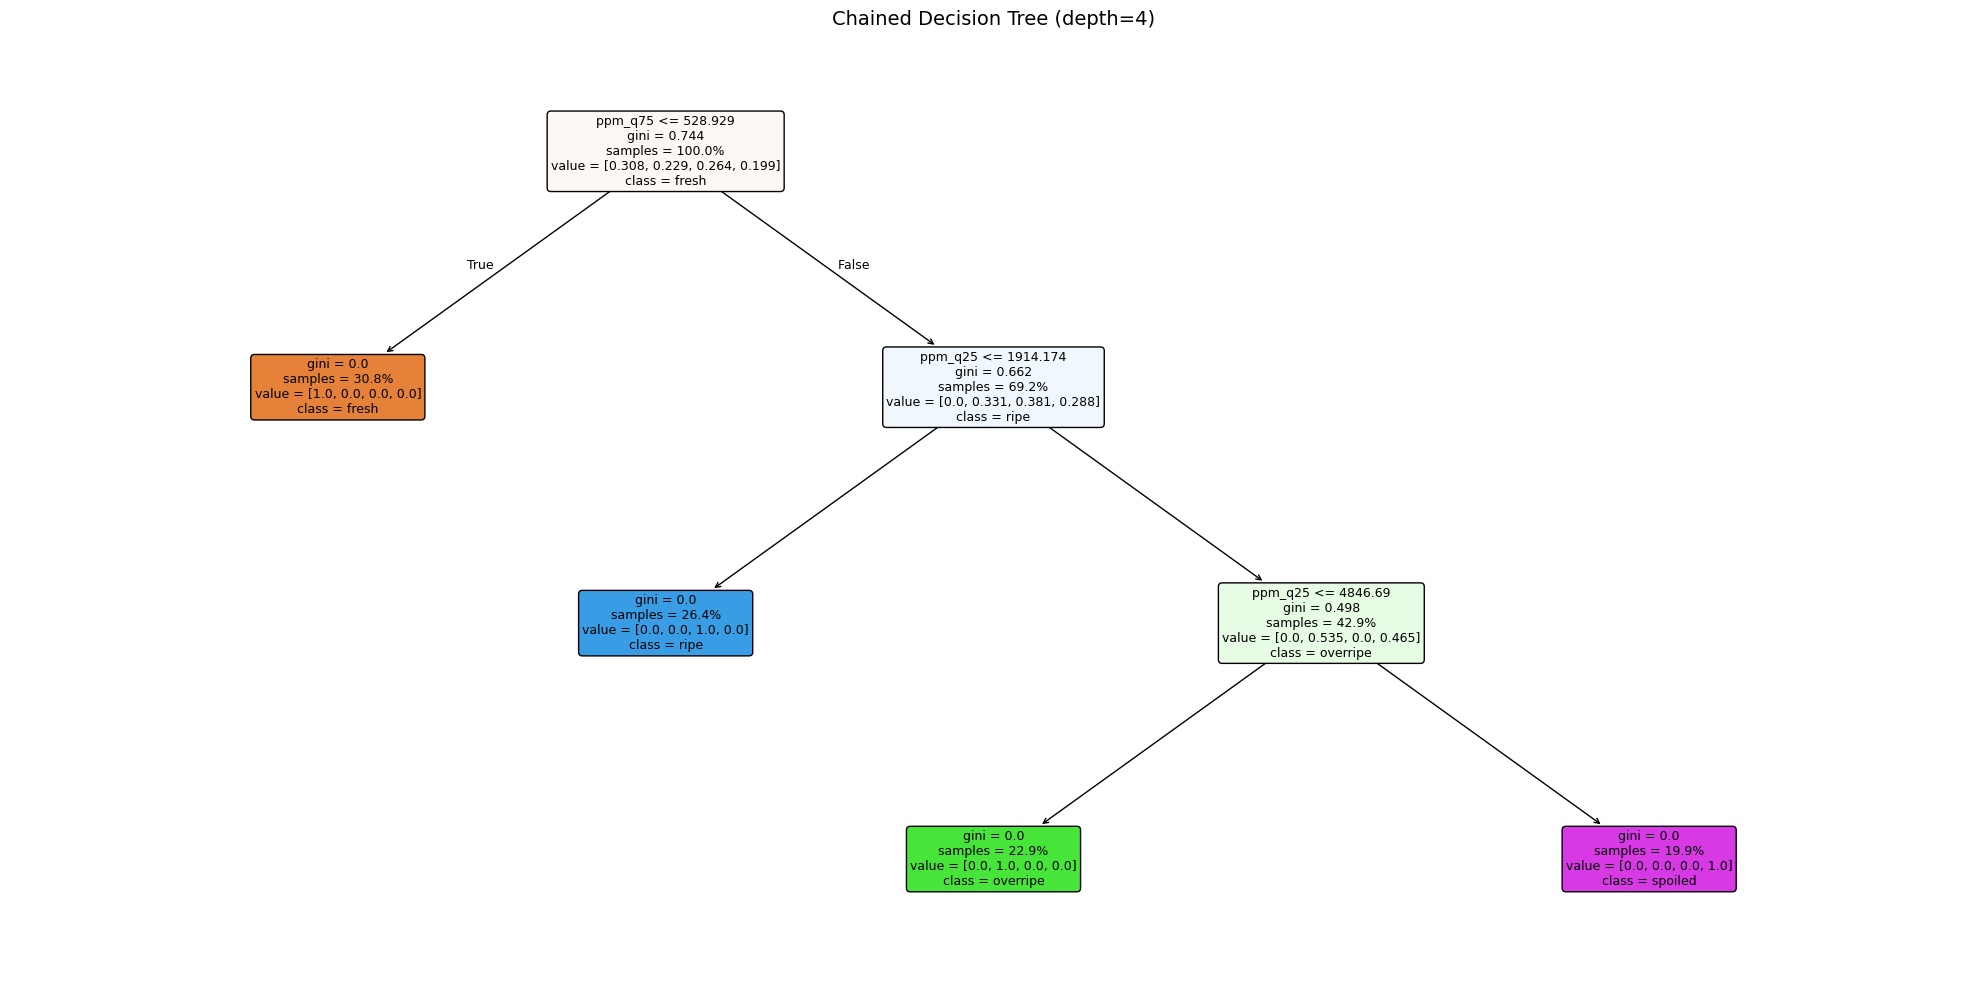

In [17]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(chained_model,
          feature_names=chained_cols,
          class_names=list(label_encoder.classes_),
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax,
          proportion=True)
ax.set_title(f'Chained Decision Tree (depth={BEST_DEPTH})', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Feature Importance — Did the CV Features Help?

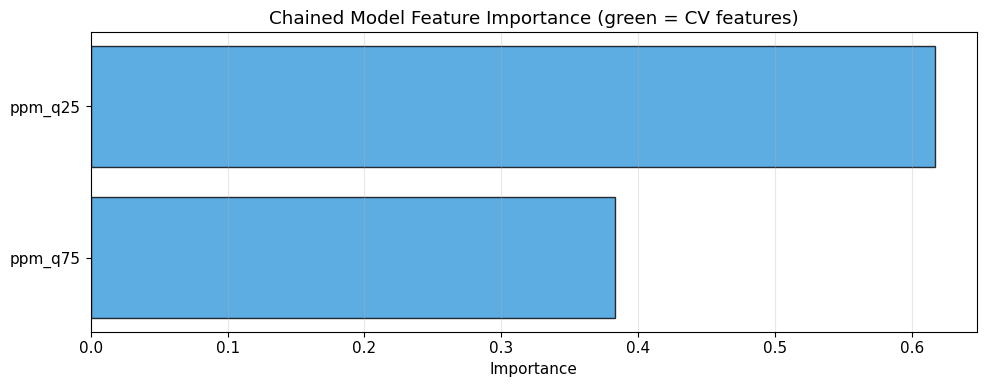

Feature importance ranking:
       ppm_q25                        0.6168 ##############################
       ppm_q75                        0.3832 ###################


In [18]:
importances = chained_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': chained_cols,
    'importance': importances,
    'is_cv': [c.startswith('cv_') for c in chained_cols]
}).sort_values('importance', ascending=True)

nonzero = importance_df[importance_df['importance'] > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(nonzero) * 0.4)))
colors = ['#27ae60' if cv else '#3498db' for cv in nonzero['is_cv']]
ax.barh(nonzero['feature'], nonzero['importance'], color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Importance')
ax.set_title('Chained Model Feature Importance (green = CV features)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Feature importance ranking:')
for _, row in importance_df[::-1].iterrows():
    if row['importance'] > 0:
        marker = '[CV]' if row['is_cv'] else '    '
        bar = '#' * int(row['importance'] * 50)
        print(f"  {marker} {row['feature']:30s} {row['importance']:.4f} {bar}")

## 14. Save the Chained Model

In [19]:
# Save the chained model
model_path = os.path.join(OUTPUT_DIR, 'freshcheck_chained_tree.joblib')
joblib.dump(chained_model, model_path)
print(f'Chained model saved: {model_path}')

# Save label encoder
encoder_path = os.path.join(OUTPUT_DIR, 'label_encoder.joblib')
joblib.dump(label_encoder, encoder_path)
print(f'Label encoder saved: {encoder_path}')

# Save config (includes feature columns in correct order!)
config = {
    'feature_columns': chained_cols,
    'gas_feature_columns': gas_only_cols,
    'cv_feature_columns': ['cv_at_least_ripe', 'cv_at_least_overripe', 'cv_at_least_spoiled'],
    'window_size': WINDOW_SIZE,
    'recent_window': RECENT_WINDOW,
    'stage_thresholds': STAGE_THRESHOLDS,
    'stage_order': STAGE_ORDER,
    'stage_to_action': STAGE_TO_ACTION,
    'sensor': SENSOR,
    'model_depth': BEST_DEPTH,
    'training_samples': len(train_idx),
    'test_accuracy': float(acc_chained),
    'test_f1_macro': float(f1_chained),
    'version': 'v8.0',
    'approach': 'chained_with_cv',
}
config_path = os.path.join(OUTPUT_DIR, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Config saved: {config_path}')

print(f'\nFeature columns for inference (in order):')
for i, col in enumerate(chained_cols, 1):
    print(f'  {i:2d}. {col}')

Chained model saved: ./models_v8/freshcheck_chained_tree.joblib
Label encoder saved: ./models_v8/label_encoder.joblib
Config saved: ./models_v8/model_config.json

Feature columns for inference (in order):
   1. hours_elapsed
   2. ppm_current
   3. ppm_std
   4. ppm_min
   5. ppm_max
   6. ppm_range
   7. ppm_cv
   8. ppm_slope
   9. ppm_r_squared
  10. ppm_q25
  11. ppm_q75
  12. ppm_iqr
  13. recent_slope
  14. ppm_acceleration
  15. v_mean
  16. v_std
  17. v_current
  18. v_slope
  19. cv_at_least_ripe
  20. cv_at_least_overripe
  21. cv_at_least_spoiled


## 15. Summary

### What v8 Adds Over v7
- Model chaining: CV stage prediction is now an input feature
- Cascading one-hot encoding preserves ordinal relationships
- Stratified train/test split on real data (more rigorous than v7's full-train approach)
- Direct comparison of gas-only vs chained performance

### Trade-offs
- **Pros:** More accurate when CV is reliable, learns to weight CV vs gas appropriately
- **Cons:** Cannot run if CV is unavailable (dependency on the CV model at inference)

### Inference Requirements
The chained model needs both the gas sliding-window features AND a CV stage prediction at inference time. The Fog RPi handles this — it pulls both gas sensor data and the CV prediction from each leaf RPi, then runs the chained model.